In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d niyarrbarman/symptom2disease
!unzip symptom2disease.zip

Dataset URL: https://www.kaggle.com/datasets/niyarrbarman/symptom2disease
License(s): CC0-1.0
  0% 0.00/43.6k [00:00<?, ?B/s]
100% 43.6k/43.6k [00:00<00:00, 143MB/s]
Archive:  symptom2disease.zip
  inflating: Symptom2Disease.csv     


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Symptom2Disease.csv")

In [ ]:
df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [ ]:
df.shape

(1200, 3)

In [ ]:
df.columns

Index(['Unnamed: 0', 'label', 'text'], dtype='object')

In [ ]:
class_counts = df['label'].value_counts()
class_counts

,count
label,
Psoriasis,50
Varicose Veins,50
Typhoid,50
Chicken pox,50
Impetigo,50
Dengue,50
Fungal infection,50
Common Cold,50
Pneumonia,50


In [ ]:
class_counts_df = class_counts.reset_index()
class_counts_df.columns = ['disease', 'count']
class_counts_df

,disease,count
0,Psoriasis,50
1,Varicose Veins,50
2,Typhoid,50
3,Chicken pox,50
4,Impetigo,50
5,Dengue,50
6,Fungal infection,50
7,Common Cold,50
8,Pneumonia,50
9,Dimorphic Hemorrhoids,50


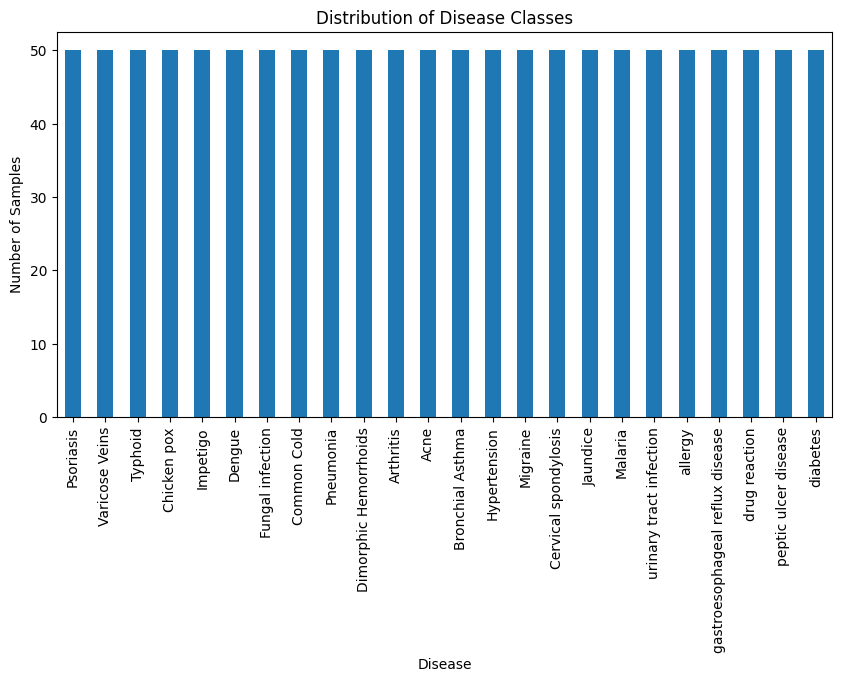

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
class_counts.plot(kind='bar')
plt.title('Distribution of Disease Classes')
plt.ylabel('Number of Samples')
plt.xlabel('Disease')
plt.show()

In [ ]:
X = df['text']
y = df['label']

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

X_clean = X.apply(clean_text)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    min_df=2,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    solver='saga',
    multi_class='ovr'
)

model.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=2000, multi_class='ovr', n_jobs=-1, solver='saga')

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9375
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       0.91      1.00      0.95        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.73      0.80      0.76        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.78      0.70      0.74        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
                        Malaria  

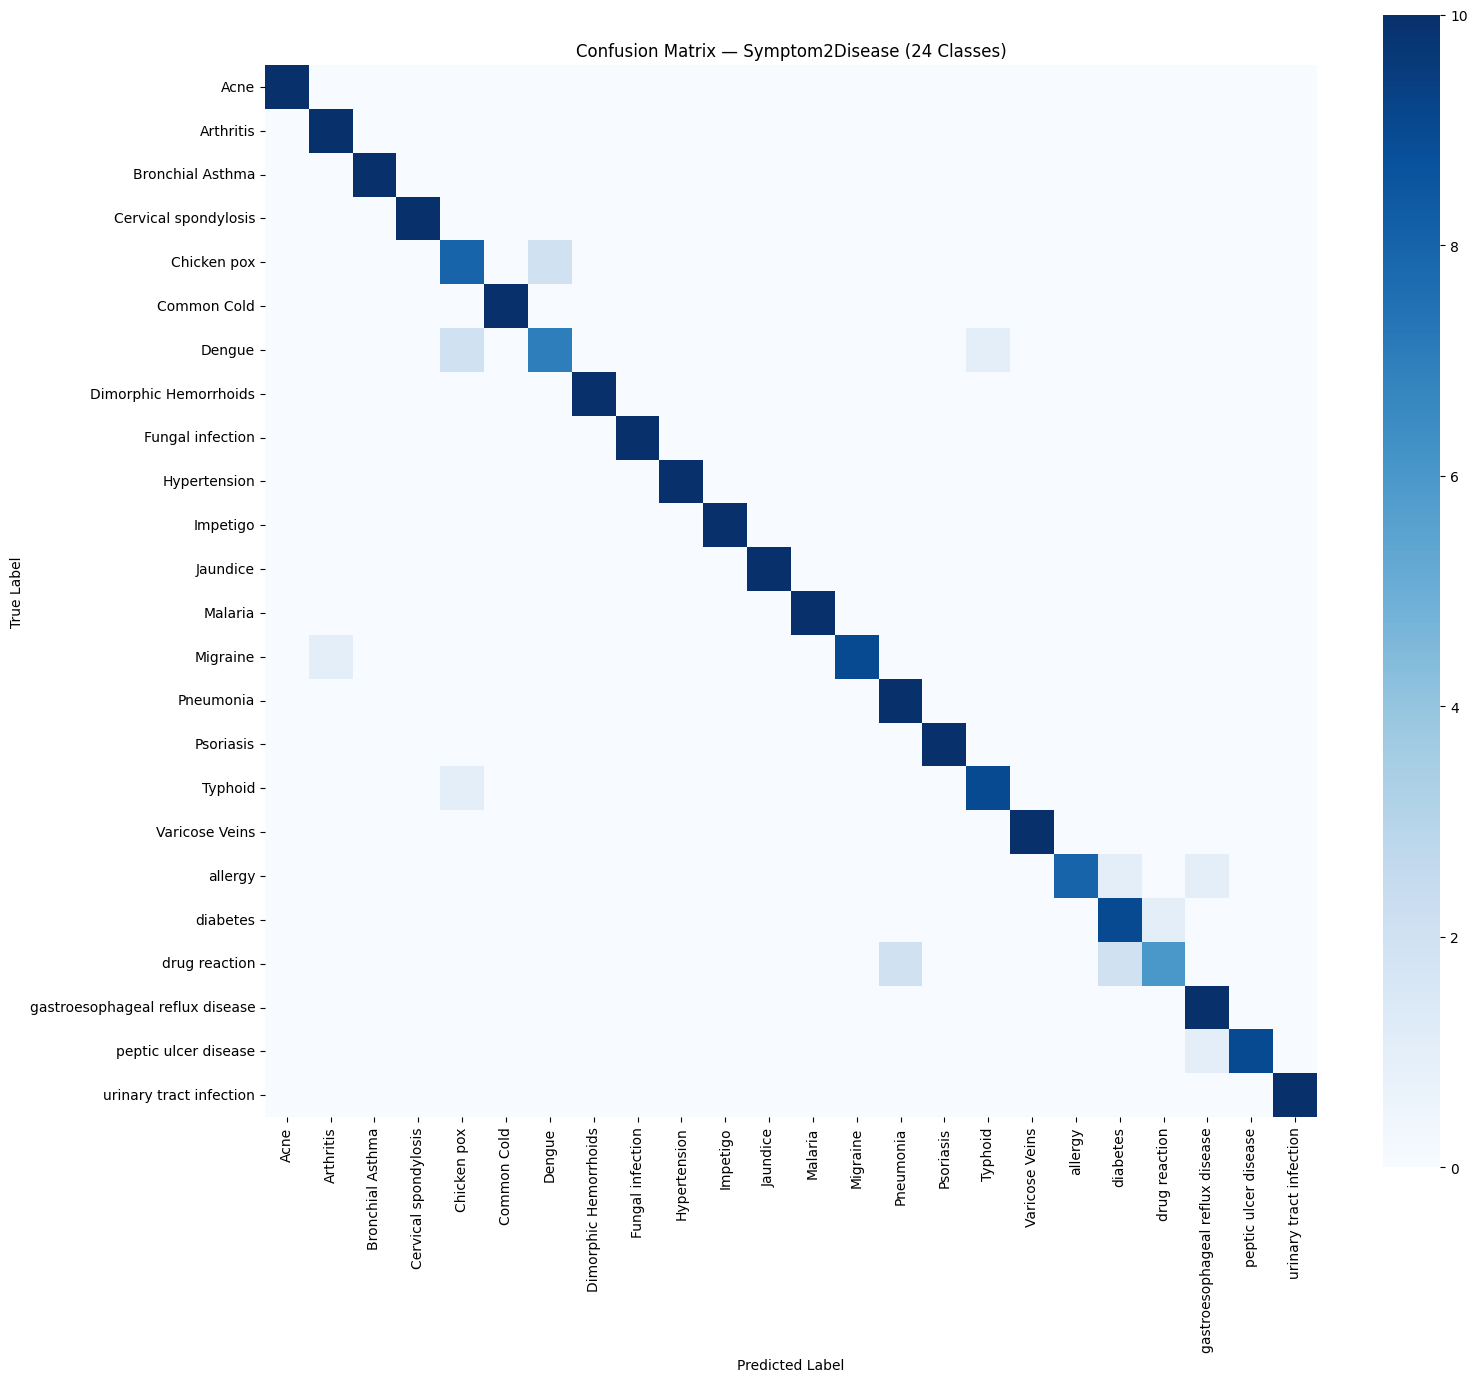

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    xticklabels=labels,
    yticklabels=labels,
    cmap='Blues',
    cbar=True,
    square=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Symptom2Disease (24 Classes)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Train-Val-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_clean, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    min_df=2,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    solver='saga',
    multi_class='ovr',
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=2000, multi_class='ovr', n_jobs=-1, solver='saga')

In [ ]:
from sklearn.metrics import classification_report

print("VALIDATION RESULT")
print(classification_report(y_val, model.predict(X_val_tfidf)))

VALIDATION RESULT
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         8
                      Arthritis       0.89      1.00      0.94         8
               Bronchial Asthma       0.78      0.88      0.82         8
           Cervical spondylosis       0.89      1.00      0.94         8
                    Chicken pox       1.00      0.88      0.93         8
                    Common Cold       1.00      0.75      0.86         8
                         Dengue       1.00      0.88      0.93         8
          Dimorphic Hemorrhoids       1.00      1.00      1.00         8
               Fungal infection       0.80      1.00      0.89         8
                   Hypertension       1.00      1.00      1.00         8
                       Impetigo       1.00      1.00      1.00         8
                       Jaundice       1.00      1.00      1.00         8
                        Malaria 

In [ ]:
print("TEST RESULT")
print(classification_report(y_test, model.predict(X_test_tfidf)))

TEST RESULT
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       0.91      1.00      0.95        10
               Bronchial Asthma       0.91      1.00      0.95        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.75      0.90      0.82        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       1.00      0.80      0.89        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
                        Malaria       

### Trial Test Case

In [ ]:
def predict_disease(text):
    text_clean = clean_text(text)
    text_tfidf = tfidf.transform([text_clean])
    pred = model.predict(text_tfidf)[0]
    proba = model.predict_proba(text_tfidf).max()
    return pred, proba

In [ ]:
text_input = "I have high fever, headache and pain behind my eyes"
prediction, confidence = predict_disease(text_input)

print("Predicted disease:", prediction)
print("Confidence:", round(confidence, 3))

Predicted disease: Dengue
Confidence: 0.225


In [ ]:
text_input = "Doctor, I have had a high fever for the last three days. The fever started suddenly and stays high even after I take medicine. I feel strong pain in my head, behind my eyes, and all over my body, especially in my joints and back. I feel very weak and tired and I have little energy to do daily activities. I also feel nauseous and have vomited once. Since this morning, I have noticed a red rash on my arms. I do not have a cough or a runny nose, but I feel dizzy when I stand up. I was recently in an area with many mosquitoes, so I am worried about my condition."
prediction, confidence = predict_disease(text_input)

print("Predicted disease:", prediction)
print("Confidence:", round(confidence, 3))

Predicted disease: Dengue
Confidence: 0.119


In [ ]:
text_input = "I have been feeling pain and a burning sensation when I urinate for the past two days. I feel the need to urinate very often, but only a small amount of urine comes out each time. My lower abdomen feels uncomfortable and sometimes painful. I have also noticed that my urine looks cloudy and has a strong smell. Since yesterday, I have felt slightly feverish and tired. I do not have vaginal discharge or back pain, but the discomfort while urinating is getting worse."
prediction, confidence = predict_disease(text_input)

print("Predicted disease:", prediction)
print("Confidence:", round(confidence, 3))

Predicted disease: urinary tract infection
Confidence: 0.199


In [ ]:
text_input = "I have been experiencing a burning sensation in my chest for the past few weeks, especially after eating meals. The discomfort usually starts in the upper part of my stomach and moves up toward my chest and throat. Sometimes I feel a sour or bitter taste in my mouth, especially when I lie down at night. I often feel bloated after eating and I burp frequently. I also feel mild nausea, but I have not vomited. The symptoms become worse after eating spicy or oily food and when I bend forward or lie flat. Because of this, my sleep has been disturbed, and I wake up at night feeling uncomfortable in my chest and throat. I do not have chest pain related to physical activity, but the burning sensation has been happening more often and is affecting my daily routine."
prediction, confidence = predict_disease(text_input)

print("Predicted disease:", prediction)
print("Confidence:", round(confidence, 3))

Predicted disease: gastroesophageal reflux disease
Confidence: 0.314


In [ ]:
text_input = "I have been feeling unusually tired and sometimes dizzy over the past month. I do not have any pain, but I occasionally notice a pounding sensation in my head, especially in the mornings. Sometimes I feel short of breath even when I am doing simple activities like walking up the stairs. I have also noticed that my heart seems to beat faster at times, without any physical exertion. I have been trying to check my blood pressure at home, and it has often been higher than normal. I feel stressed and anxious because I do not know the cause of these symptoms, and they have started affecting my sleep and focus at work. I do not experience chest pain or fainting, but the constant fatigue and occasional headaches make me concerned about my overall health. I also have a family history of heart disease, which makes me worried that these symptoms could indicate something serious."
prediction, confidence = predict_disease(text_input)

print("Predicted disease:", prediction)
print("Confidence:", round(confidence, 3))

Predicted disease: Hypertension
Confidence: 0.082


In [ ]:
text_input = "Increased thirst, frequent urination, unexplained weight loss, and fatigue."
prediction, confidence = predict_disease(text_input)

print("Predicted disease:", prediction)
print("Confidence:", round(confidence, 3))

Predicted disease: diabetes
Confidence: 0.081


### keywords

In [ ]:
import numpy as np
import pandas as pd

feature_names = np.array(tfidf.get_feature_names_out())
coef = model.coef_
classes = model.classes_

In [ ]:
top_n = 20
rows = []

for i, disease in enumerate(classes):
    top_idx = np.argsort(coef[i])[-top_n:][::-1]
    top_words = feature_names[top_idx]

    rows.append({
        "disease": disease,
        "words": ", ".join(top_words)
    })

df_top_words = pd.DataFrame(rows)
df_top_words


,disease,words
0,Acne,"pus, blackheads, pimples, filled, skin, filled..."
1,Arthritis,"stiff, joints, walking, neck, muscles, difficu..."
2,Bronchial Asthma,"cough, fever, mucoid, breathing, lot mucoid, v..."
3,Cervical spondylosis,"neck hurts, neck, weakness, cough, hurts, pain..."
4,Chicken pox,"red spots, spots, red, lymph nodes, lymph, nod..."
5,Common Cold,"sinuses, sneezing, smell, throat, exhausted, s..."
6,Dengue,"accompanied, pain, eyes, pain eyes, rashes, de..."
7,Dimorphic Hemorrhoids,"anus, stool, painful, really, anus really, anu..."
8,Fungal infection,"skin, bumps, different, rest, patches, lumps, ..."
9,Hypertension,"chest pain, headache chest, dizziness, pain di..."


In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())
coef = model.coef_
labels = model.classes_

TOP_N = 20  # jumlah kata per disease

for i, disease in enumerate(labels):
    top_idx = np.argsort(coef[i])[-TOP_N:][::-1]
    top_words = feature_names[top_idx]

    print(f"{disease}:")
    print(list(top_words))
    print("-" * 80)


Acne:
['pus', 'blackheads', 'pimples', 'filled', 'skin', 'filled pimples', 'pus filled', 'rash', 'rash skin', 'pimples blackheads', 'blackheads pus', 'scurrying', 'morning', 'blackheads skin', 'blackheads pimples', 'additionally skin', 'sensitive', 'scurring', 'nasty rash', 'skin scurrying']
--------------------------------------------------------------------------------
Arthritis:
['stiff', 'joints', 'walking', 'neck', 'muscles', 'difficult', 'swollen', 'stiffness', 'uncomfortable', 'walk', 'really', 'weak', 'weakness', 'neck really', 'joints swollen', 'stiff walking', 'stiff joints', 'really stiff', 'weak neck', 'swollen joints']
--------------------------------------------------------------------------------
Bronchial Asthma:
['cough', 'fever', 'mucoid', 'breathing', 'lot mucoid', 've coughing', 'high', 'coughing lot', 'coughing', 'mucoid sputum', 'sputum', 've', 'persistent cough', 'cough breathing', 'persistent', 'high fever', 'producing', 'lot mucus', 'mucus', 'lot']
------------